## Computational Holography

c:\Users\Aakas\anaconda3\envs\kyoung\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Aakas\anaconda3\envs\kyoung\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


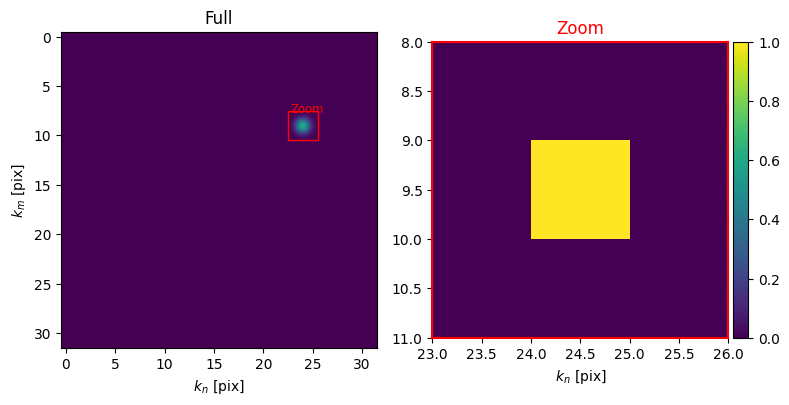

In [1]:
# Import phase retrieval algorithms
import numpy as np
from slmsuite.holography.algorithms import Hologram

# Make the desired image: a random pixel targeted in a 32x32 grid
target_size = (32, 32)
target = np.zeros(target_size)
target[9, 24] = 1

# Initialize the hologram and plot the target
# Note: For now, we'll assume the SLM and target are the same size (since they're a Fourier pair)
slm_size = target_size
hologram = Hologram(target, slm_shape=slm_size)
zoombox = hologram.plot_farfield(source=hologram.target, cbar=True)

In [2]:
# Create a virtual SLM and camera
from slmsuite.hardware.slms.simulated import SimulatedSLM
from slmsuite.hardware.cameras.simulated import SimulatedCamera
from slmsuite.hardware.cameraslms import FourierSLM

# Assume a 532 nm laser
wav_um = 0.532
slm = SimulatedSLM((slm_size[1], slm_size[0]), pitch_um=(10, 10), wav_um=wav_um)
camera = SimulatedCamera(slm)

# The setup (a FourierSLM setup with a camera placed in the Fourier plane of an SLM) holds the camera and SLM.
setup = FourierSLM(camera, slm)
hologram.cameraslm = setup

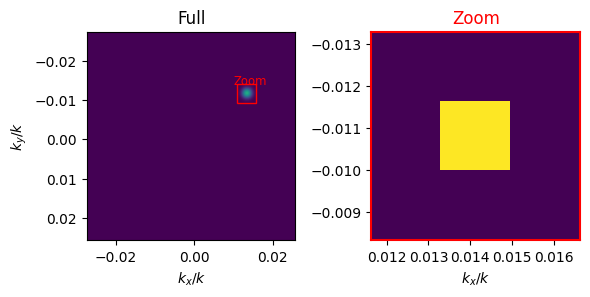

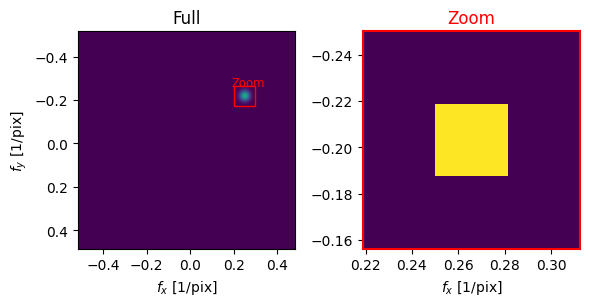

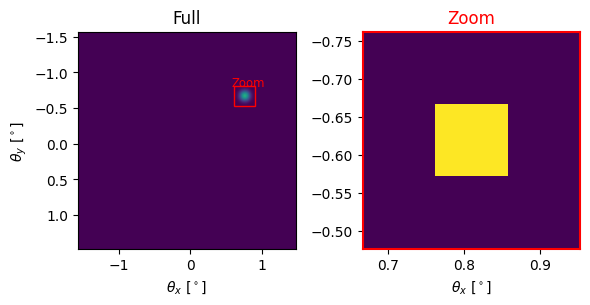

In [3]:
# Not all inclusive, but try out a few units
for units in ["kxy", "freq", "deg"]:
    hologram.plot_farfield(source=hologram.target, units=units, figsize=(6,3))

100%|██████████| 5/5 [00:00<00:00, 747.06it/s]


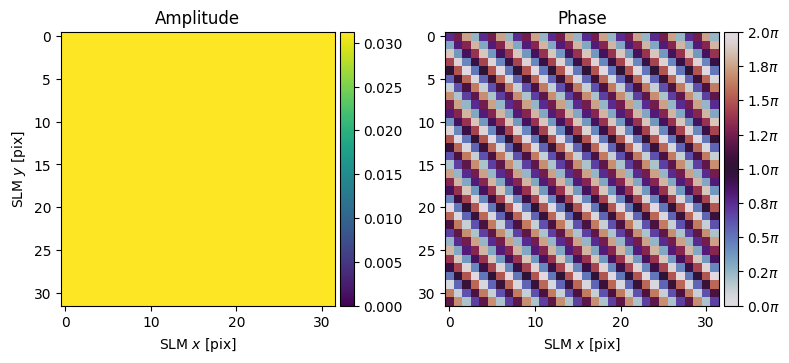

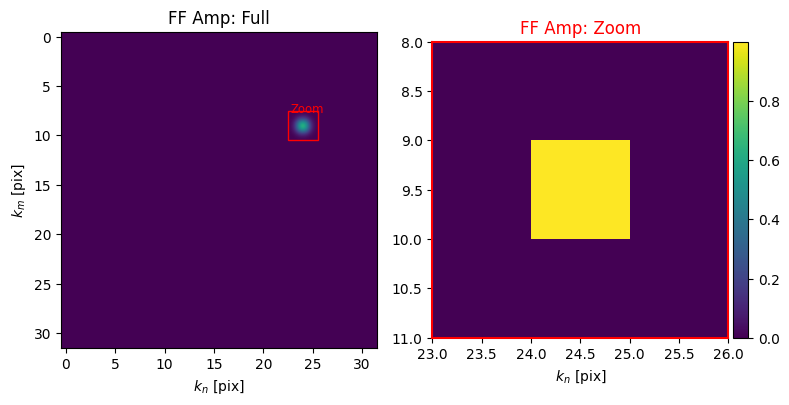

In [4]:
# Run 5 iterations of GS.
hologram.optimize(method='GS', maxiter=5)

# Look at the associated near- and far- fields
hologram.plot_nearfield(cbar=True)
hologram.plot_farfield(limits=zoombox, cbar=True, title='FF Amp');

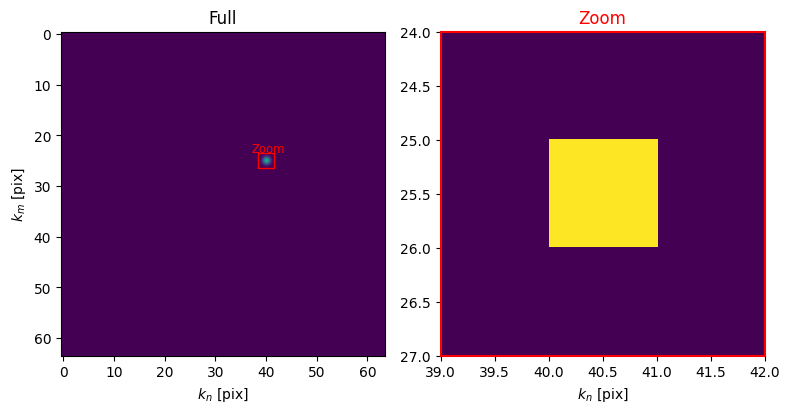

100%|██████████| 5/5 [00:00<?, ?it/s]


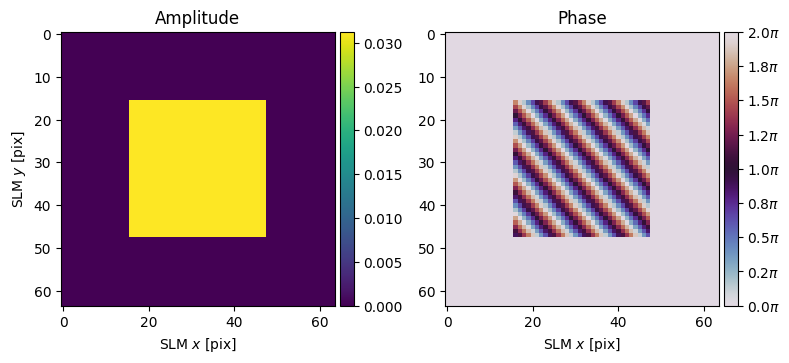

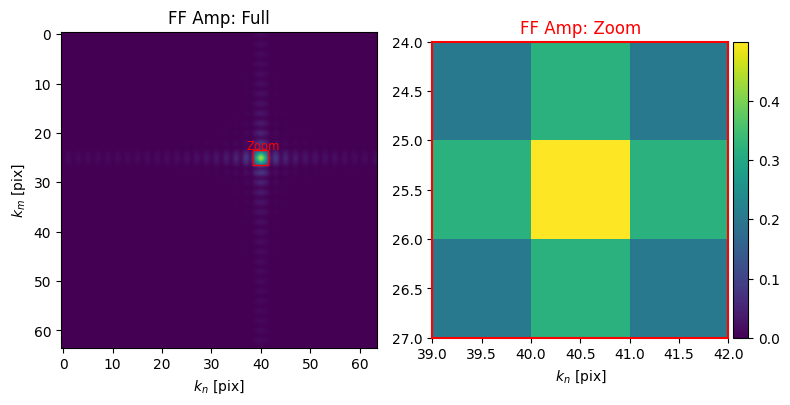

[array([39, 42]), array([24, 27])]

In [5]:
from slmsuite.holography import toolbox

# Get the padding needed to resolve 2x smaller than a diffraction limited spot
# (N.b. slm.pitch, like all length variables in slmsuite, is wavelength-normalized)
hologram.shape = hologram.get_padded_shape(setup, precision=0.5/(slm.pitch[0]*slm.shape[0]))
target_padded = toolbox.pad(target, hologram.shape)

# Recompute the farfield
hologram = Hologram(target_padded, slm_shape=slm.shape)
zoombox_padded = hologram.plot_farfield(target_padded)
hologram.optimize(method='GS', maxiter=5)

# Look at the associated near- and far- fields
hologram.plot_nearfield(padded=True, cbar=True)
hologram.plot_farfield(cbar=True, units="deg", title='FF Amp', limits=zoombox_padded)

100%|██████████| 5/5 [00:00<00:00, 651.73it/s]


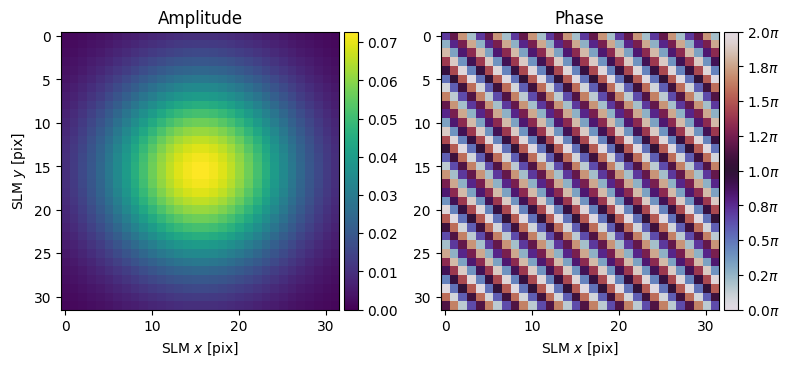

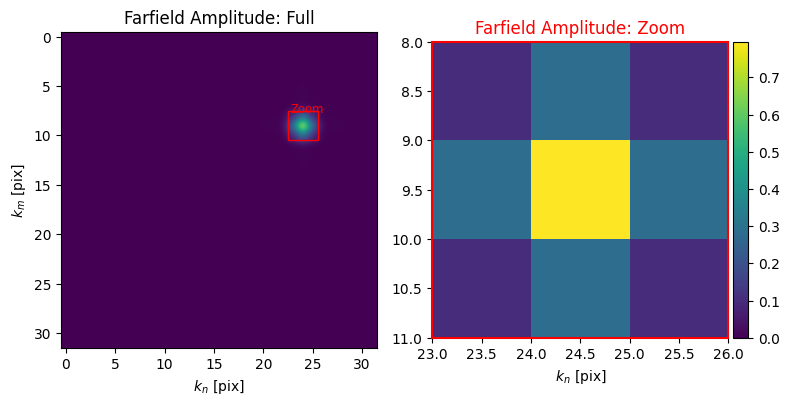

[array([23, 26]), array([ 8, 11])]

In [6]:
# Set a Gaussian amplitude profile on SLM
slm.set_source_analytic()   # With no arguments, defaults to a beamradius equal to half the aperture size

# Redo the same GS calculations
hologram = Hologram(target, slm_shape=slm.shape, amp=slm.source["amplitude"])
hologram.optimize(method='GS', maxiter=5)

hologram.plot_nearfield(padded=True,cbar=True)
hologram.plot_farfield(cbar=True,limits=zoombox)

## Creating 2 Traps

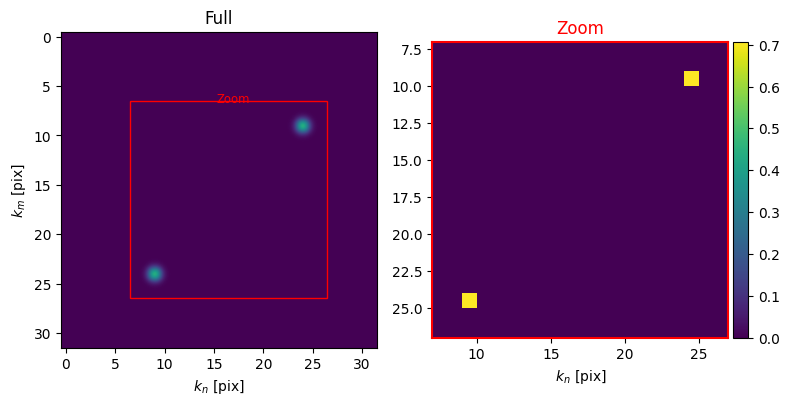

In [7]:
target_size = (32, 32)
target = np.zeros(target_size)
target[9, 24] = 1
target[24, 9] = 1

# Initialize the hologram and plot the target
# Note: For now, we'll assume the SLM and target are the same size (since they're a Fourier pair)
slm_size = target_size
hologram = Hologram(target, slm_shape=slm_size)
zoombox = hologram.plot_farfield(source=hologram.target, cbar=True)

In [8]:
wav_um = 0.532
slm = SimulatedSLM((slm_size[1], slm_size[0]), pitch_um=(10, 10), wav_um=wav_um)
camera = SimulatedCamera(slm)

# The setup (a FourierSLM setup with a camera placed in the Fourier plane of an SLM) holds the camera and SLM.
setup = FourierSLM(camera, slm)
hologram.cameraslm = setup

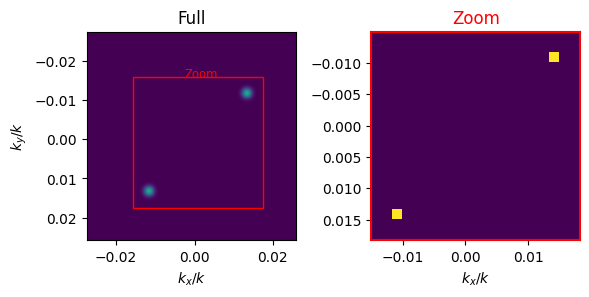

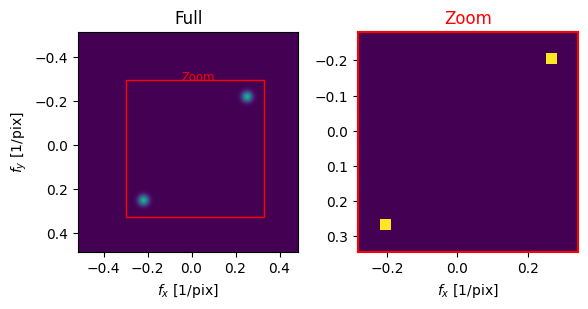

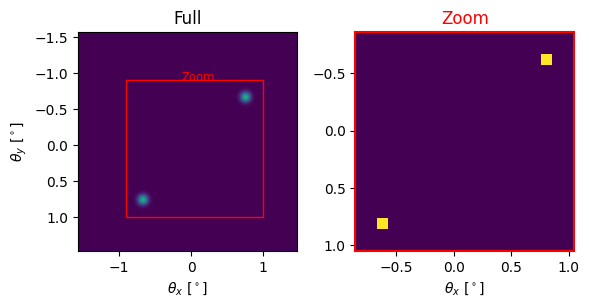

In [9]:
# Not all inclusive, but try out a few units
for units in ["kxy", "freq", "deg"]:
    hologram.plot_farfield(source=hologram.target, units=units, figsize=(6,3))

  0%|          | 0/25 [00:00<?, ?it/s]c:\Users\Aakas\anaconda3\envs\kyoung\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:1819: RuntimeWarning: divide by zero encountered in divide
  xp.divide(feedback_corrected, xp.array(target_amp, copy=(False if np.__version__[0] == '1' else None)), out=feedback_corrected)
c:\Users\Aakas\anaconda3\envs\kyoung\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:1819: RuntimeWarning: invalid value encountered in divide
  xp.divide(feedback_corrected, xp.array(target_amp, copy=(False if np.__version__[0] == '1' else None)), out=feedback_corrected)
100%|██████████| 25/25 [00:00<00:00, 946.39it/s]


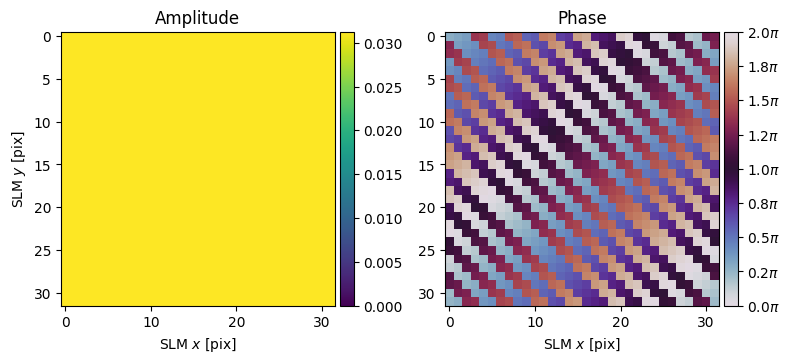

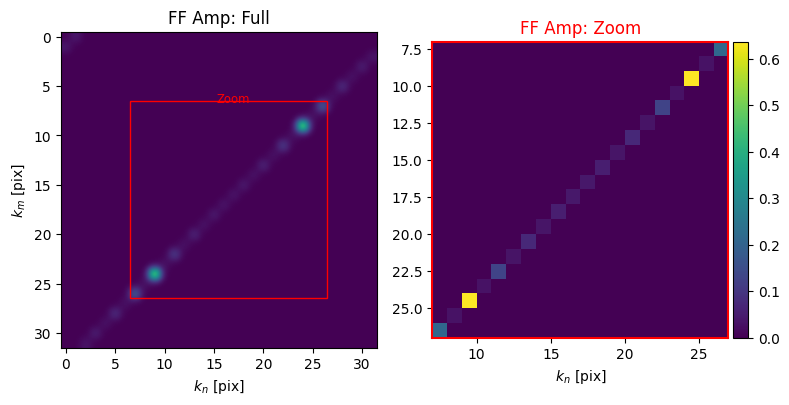

In [16]:
# Run 5 iterations of GS.
hologram.optimize(method='WGS-Leonardo', maxiter=25)

# Look at the associated near- and far- fields
hologram.plot_nearfield(cbar=True)
hologram.plot_farfield(limits=zoombox, cbar=True, title='FF Amp');

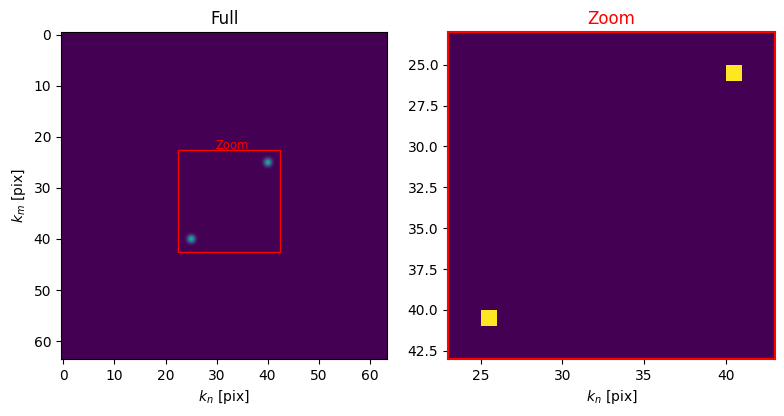

100%|██████████| 5/5 [00:00<00:00, 429.48it/s]


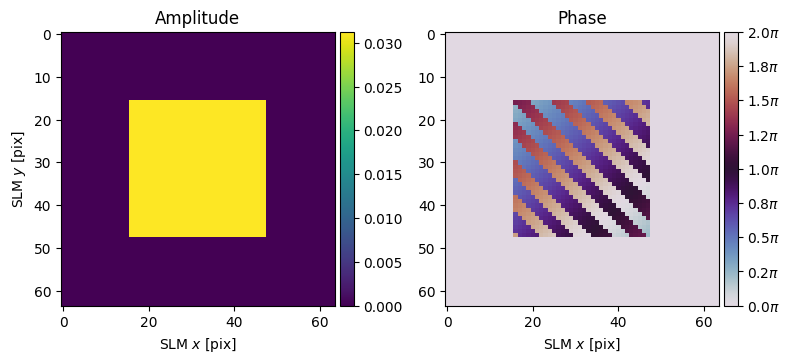

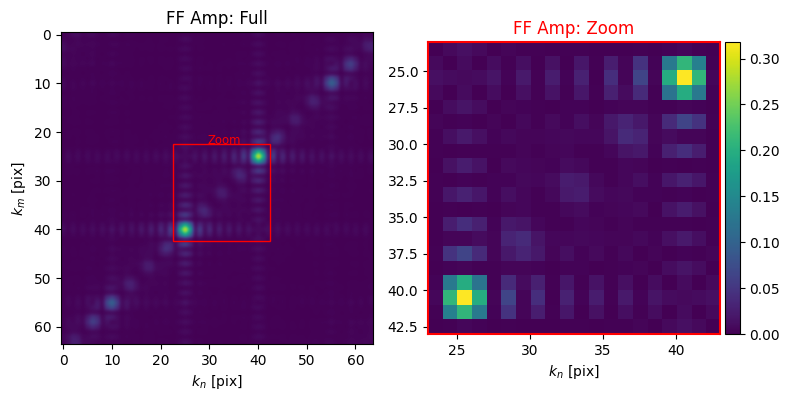

[array([23, 43]), array([23, 43])]

In [17]:
# Get the padding needed to resolve 2x smaller than a diffraction limited spot
# (N.b. slm.pitch, like all length variables in slmsuite, is wavelength-normalized)
hologram.shape = hologram.get_padded_shape(setup, precision=0.5/(slm.pitch[0]*slm.shape[0]))
target_padded = toolbox.pad(target, hologram.shape)

# Recompute the farfield
hologram = Hologram(target_padded, slm_shape=slm.shape)
zoombox_padded = hologram.plot_farfield(target_padded)
hologram.optimize(method='GS', maxiter=5)

# Look at the associated near- and far- fields
hologram.plot_nearfield(padded=True, cbar=True)
hologram.plot_farfield(cbar=True, units="deg", title='FF Amp', limits=zoombox_padded)